# Homework

### Problem 1
Implement serial test and apply to a `samples`

In [ ]:
import numpy as np
from scipy import stats

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

samples = [rng() for _ in range(1000)]

points = [(samples[i-1], samples[i]) for i in range(1, len(samples))][::2]

x = [points[i][0] for i in range(len(points))]
y = [points[i][1] for i in range(len(points))]

k = 20
f_obs = np.histogram2d(x, y, bins=[k, k])[0]

per_bin = len(points) / (k * k)
f_exp = np.full(k*k, per_bin)

result = stats.chisquare(f_obs.flatten(), f_exp)
print(result)

Power_divergenceResult(statistic=np.float64(386.40000000000003), pvalue=np.float64(0.6653662117152015))


### Problem 2*
Implement permutation test and apply to a `samples`

In [ ]:
from itertools import permutations
from scipy.stats import chi2
import numpy as np

block_length = 3

subsequences = [samples[j:j+block_length] for j in range(0, len(samples) - block_length + 1, block_length)]

all_orders = list(permutations(range(block_length)))
counts = np.zeros(len(all_orders), dtype=int)

for subseq in subsequences:
    order = tuple(np.argsort(subseq))
    idx = all_orders.index(order)
    counts[idx] += 1

expected = len(subsequences) / len(all_orders)

statistic = np.sum((counts - expected) ** 2 / expected)
pval = 1 - chi2.cdf(statistic, len(all_orders)-1)

print(f'Chi-square: {statistic:.4f}')
print(f'p-value: {pval:.4f}')
if pval < 0.05:
    print('Sequence fails the permutation test (not uniformly random).')
else:
    print('Sequence passes the permutation test (uniformly random).')

Chi-square: 4.8559
p-value: 0.4337
Sequence passes the permutation test (uniformly random).


### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [ ]:
import numpy as np
from itertools import permutations
from scipy.stats import chisquare

def rng_bad():
    rng_bad.current = (65539 * rng_bad.current) % (2**31)
    return rng_bad.current / 2**31
rng_bad.current = 1

def rng_good():
    return np.random.uniform(0, 1)

sample_bad = [rng_bad() for _ in range(1000)]
sample_good = [rng_good() for _ in range(1000)]

def permutation_test(sample, d=3):
    perms = list(permutations(range(d)))
    freq = np.zeros(len(perms), int)
    blocks = [sample[i:i+d] for i in range(0, len(sample)-d+1, d)]
    for block in blocks:
        idx = perms.index(tuple(np.argsort(block)))
        freq[idx] += 1
    exp = len(blocks) / len(perms)
    stat, pval = chisquare(freq, [exp]*len(perms))
    return pval

p_bad = permutation_test(sample_bad)
p_good = permutation_test(sample_good)

print('Bad RNG permutation test p-value:', p_bad)
print('Good RNG permutation test p-value:', p_good)

Bad RNG permutation test p-value: 0.7580774481043864
Good RNG permutation test p-value: 0.5716703807828415


### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

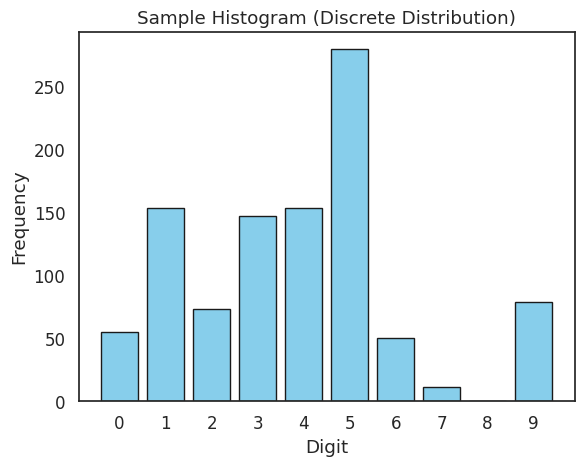

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

digits = np.arange(10)
probabilities = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])

sorted_idx = np.argsort(-probabilities)
digits_sorted = digits[sorted_idx]
prob_sorted = probabilities[sorted_idx]
prob_sorted /= prob_sorted.sum()

sample = np.random.choice(digits_sorted, 1000, p=prob_sorted)

plt.bar(digits_sorted, [np.sum(sample == val) for val in digits_sorted], width=0.8, color='skyblue', edgecolor='k')
plt.xticks(digits_sorted)
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("Sample Histogram (Discrete Distribution)")
plt.show()

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_288/908747299.py:19: SyntaxWarning: invalid escape sequence '\l'
  plt.title('Histogram and Density for Exp($\lambda$)')


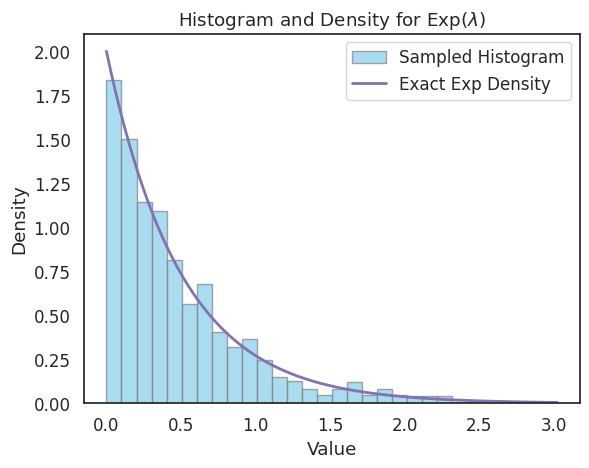

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lam = 2.0
size = 1000

uniform_vals = np.random.uniform(0, 1, size)

exp_sample = -np.log(uniform_vals) / lam

plt.hist(exp_sample, bins=30, density=True, color='skyblue', alpha=0.7, label='Sampled Histogram', edgecolor='gray')

xx = np.linspace(0, exp_sample.max(), 300)
density = lam * np.exp(-lam * xx)
plt.plot(xx, density, 'm-', lw=2, label='Exact Exp Density')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histogram and Density for Exp($\lambda$)')
plt.legend()
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

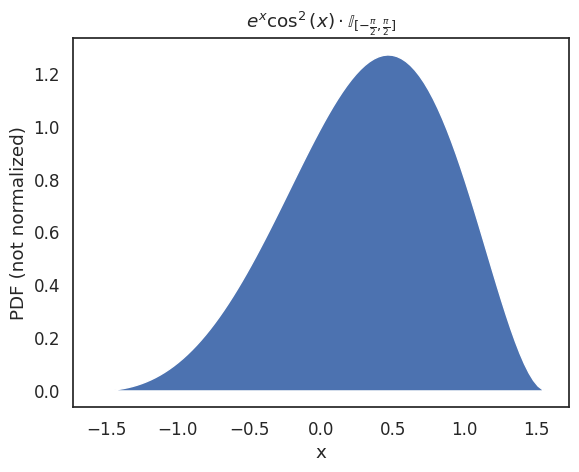

In [ ]:
fig = plt.figure()

x = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x) * np.cos(x) ** 2 # not normalized density!
plt.fill_between(x, 0, density)
plt.ylabel('PDF (not normalized)')
plt.xlabel('x')
plt.title(r'$e^x \cos^2(x) \cdot \mathbb{I}_{[-\frac{\pi}{2}, \frac{\pi}{2}]}$')

plt.show()

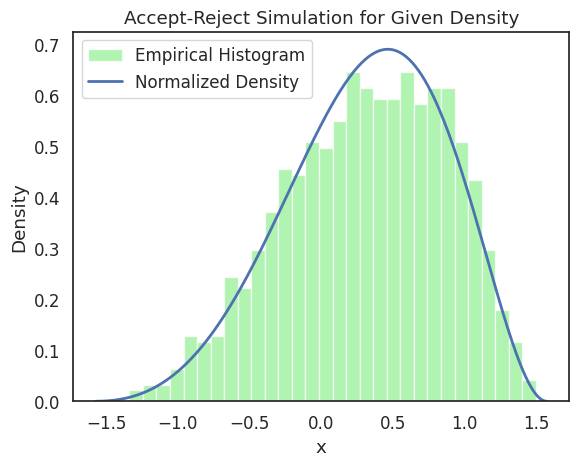

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def unnorm_density(x):
    return np.exp(x) * np.cos(x)**2

normalization, _ = quad(unnorm_density, -np.pi/2, np.pi/2)
def target_density(x):
    return unnorm_density(x) / normalization

N = 1000
results = []
while len(results) < N:
    prop = np.random.uniform(-np.pi/2, np.pi/2)
    y = np.random.uniform(0, 1)
    if y < (np.exp(prop) * (np.cos(prop)**2)):
        results.append(prop)

results = np.array(results)

plt.hist(results, bins=30, density=True, color='lightgreen', alpha=0.7, label='Empirical Histogram')

xx = np.linspace(-np.pi/2, np.pi/2, 300)
plt.plot(xx, target_density(xx), 'b', lw=2, label='Normalized Density')

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Accept-Reject Simulation for Given Density")
plt.legend()
plt.show()

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

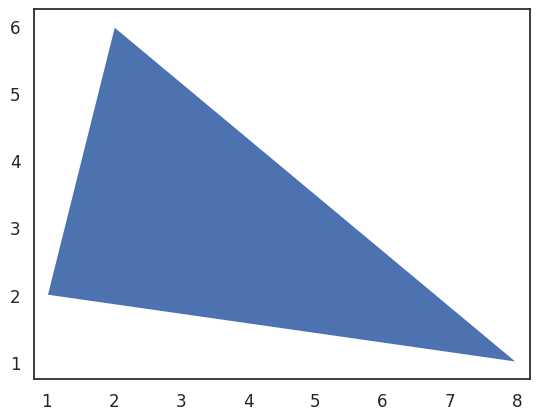

In [ ]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

fig = plt.figure()

polygon = Polygon(xy=np.array([[1, 2], [2, 6], [8, 1]]), closed=True)
plt.gca().add_collection(PatchCollection([polygon]))
plt.axis('equal')
plt.show()

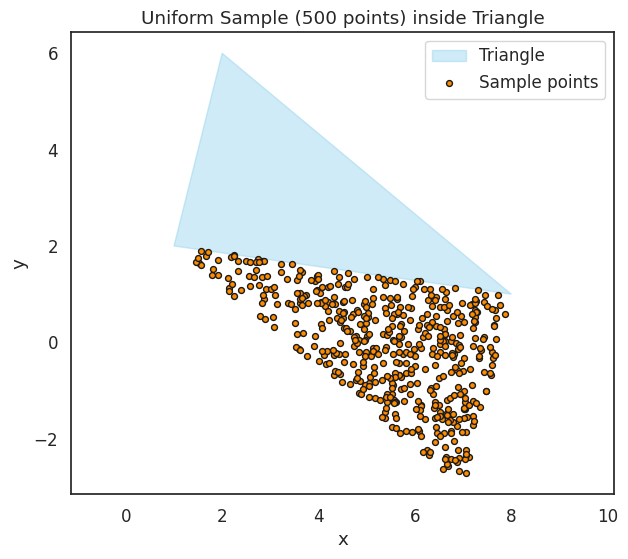

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

n_points = 500

U = np.random.rand(n_points, 2)
U_sorted = np.sort(U, axis=1)
u = U_sorted[:,0]
v = U_sorted[:,1]

samples = (1-u)[:,None]*A + (u-v)[:,None]*B + v[:,None]*C

plt.figure(figsize=(7,6))
plt.fill([A[0], B[0], C[0]], [A[1], B[1], C[1]], color='skyblue', alpha=0.4, label="Triangle")
plt.scatter(samples[:,0], samples[:,1], s=18, c='darkorange', edgecolors='k', label="Sample points")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Uniform Sample (500 points) inside Triangle')
plt.legend()
plt.axis('equal')
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

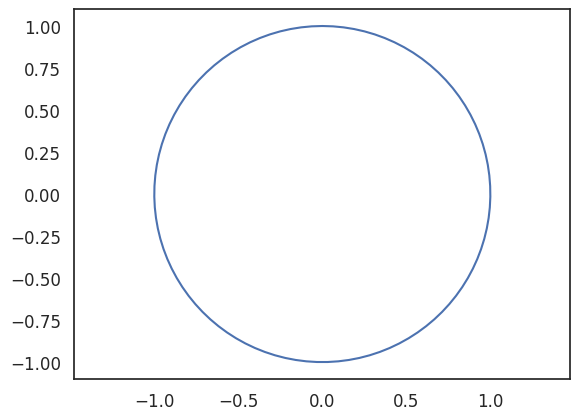

In [ ]:
fig = plt.figure()

t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()

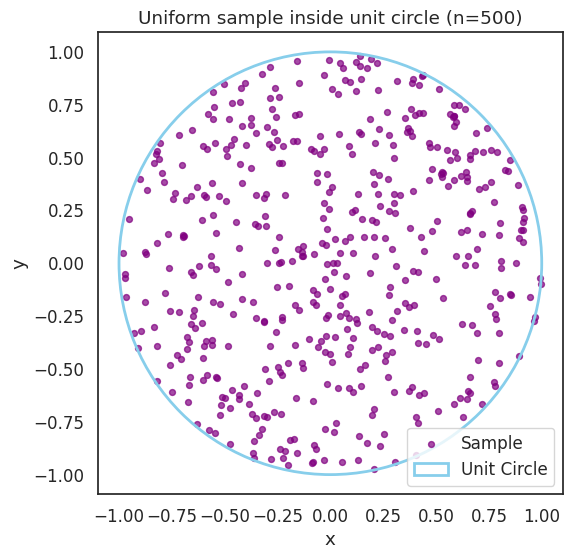

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 500

r = np.sqrt(np.random.uniform(0, 1, n))
theta = np.random.uniform(0, 2*np.pi, n)

x = r * np.cos(theta)
y = r * np.sin(theta)

plt.figure(figsize=(6,6))
plt.scatter(x, y, color='purple', s=18, alpha=0.7, label='Sample')
circle = plt.Circle((0,0), 1, color='skyblue', fill=False, lw=2, label='Unit Circle')
plt.gca().add_patch(circle)
plt.axis('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Uniform sample inside unit circle (n=500)')
plt.legend()
plt.show()

# Random normal generator

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

In [ ]:
import seaborn as sns

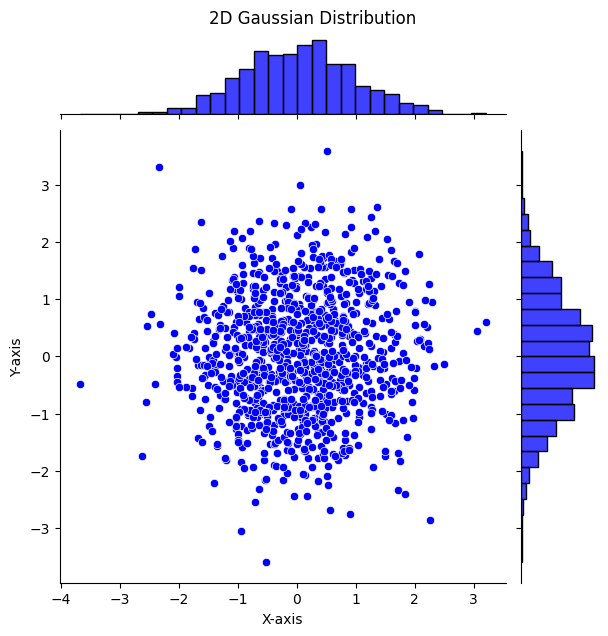

In [ ]:
n = 1000
u1, u2 = np.random.rand(2, n)
r = np.sqrt(-2 * np.log(u1))
theta = 2 * np.pi * u2
x = r * np.cos(theta)
y = r * np.sin(theta)


joint_plot = sns.jointplot(x=x, y=y, color="blue")
joint_plot.set_axis_labels('X-axis', 'Y-axis')
plt.suptitle('2D Gaussian Distribution', y=1.02)
plt.show()

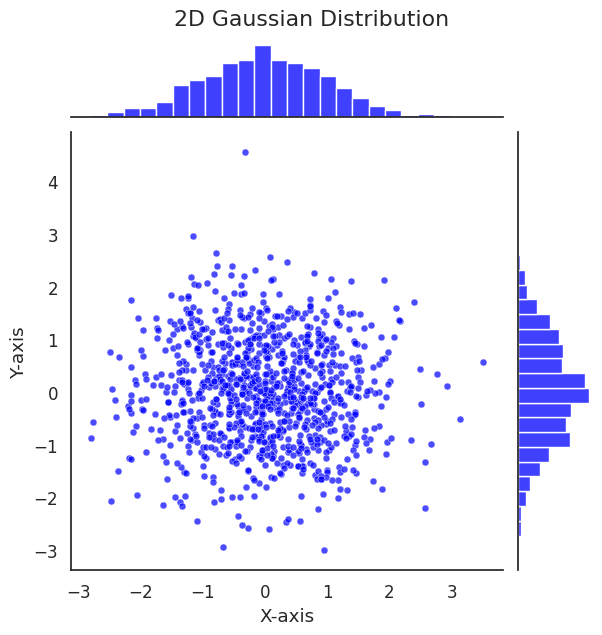

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

n = 1000

z1 = []
z2 = []
while len(z1) < n:
    u1, u2 = np.random.uniform(-1, 1, size=2)
    s = u1**2 + u2**2
    if 0 < s < 1:
        scale = np.sqrt(-2 * np.log(s) / s)
        z1.append(u1 * scale)
        z2.append(u2 * scale)
z1 = np.array(z1)
z2 = np.array(z2)

sns.set(style="white", font_scale=1.1)
g = sns.jointplot(x=z1, y=z2, color="blue", s=25, alpha=0.7)
g.set_axis_labels('X-axis', 'Y-axis')
g.fig.suptitle("2D Gaussian Distribution", y=1.02)
plt.show()

### Problem 10*

Implement a method of generating a random partition of an n-element set into subsets. Use it to estimate the expected number of subsets in a random partition of a set of 100 elements.

Hint 1: Ширяев, Вероятность, т1, задача 2 к параграфу 1.

Hint 2: http://djalil.chafai.net/blog/2012/05/03/generating-uniform-random-partitions/

In [ ]:
import numpy as np

def random_partition(n):
    partition = []
    for i in range(n):
        if len(partition) == 0 or np.random.rand() < 1/(i+1):
            partition.append([i])
        else:
            idx = np.random.choice(len(partition))
            partition[idx].append(i)
    return partition

n = 100
num_runs = 2000
subset_counts = []
for _ in range(num_runs):
    partition = random_partition(n)
    subset_counts.append(len(partition))

print("Оценённое среднее число подмножеств:", np.mean(subset_counts))

Оценённое среднее число подмножеств: 5.236


# Basic distributions
- **Uniform distribution $\operatorname{U}[a, b]$**:
$$p(x) = \frac{1}{b-a}\cdot\mathbb{I}_{x\in[a, b]}$$

- **Exponential distribution $\operatorname{Exp}(\lambda)$**:
$$p(x) = \lambda e^{-\lambda x}\cdot\mathbb{I}_{x\geqslant0}$$

- **Normal distribution $\mathcal{N}(\mu, \sigma^2)$**:
$$p(x) = \frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

- **Gamma distribution $\operatorname{Gamma}(\alpha, \lambda)$**:
$$p(x) = \frac{\lambda^\alpha}{\Gamma(\alpha)}x^{\alpha-1}e^{-\lambda x}\cdot\mathbb{I}_{x\geqslant0}$$

- **Beta distribution $\operatorname{Beta}(\alpha, \beta)$**:
$$p(x) = \frac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}x^{\alpha-1}(1-x)^{\beta-1}\cdot\mathbb{I}_{x\in[0, 1]}$$

- **$\chi^2$ distribution with $k$ degrees of freedom $\chi^2(k)$**:
$$p(x) = \frac{1}{2^{k/2}\Gamma(k/2)}x^{k/2-1}e^{-x/2}\cdot\mathbb{I}_{x\geqslant0}$$



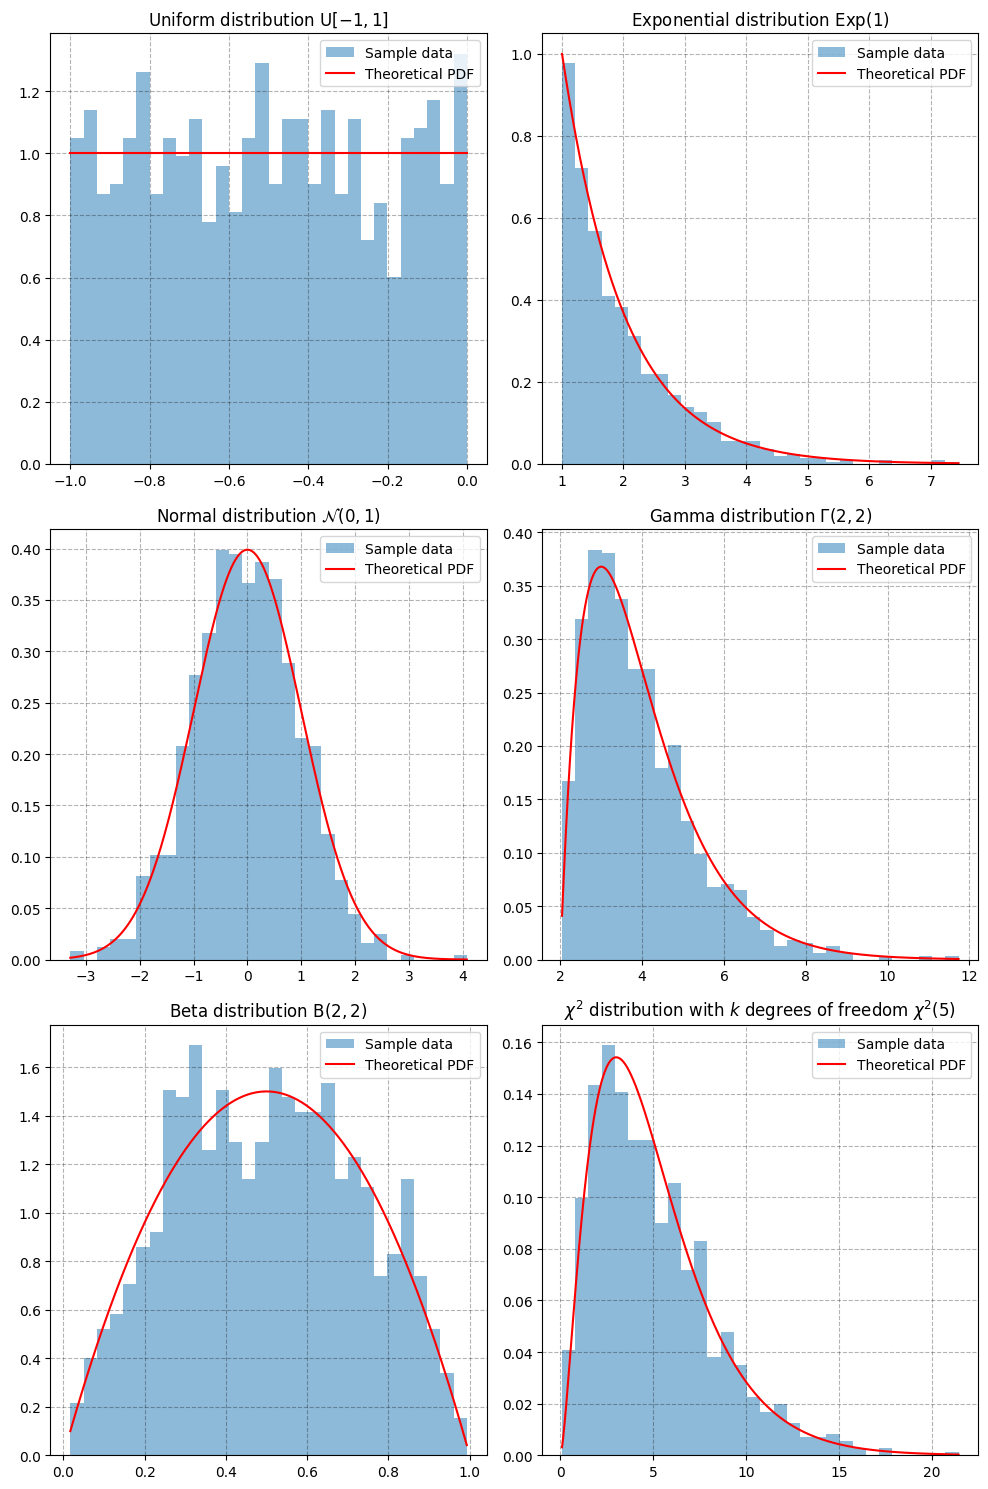

In [ ]:
# Define distributions and their parameters
distributions = [
    ("Uniform distribution $\\operatorname{U}[-1, 1]$", stats.uniform, (-1, 1)),
    ("Exponential distribution $\\operatorname{Exp}(1)$", stats.expon, (1,)),
    ("Normal distribution $\\mathcal{N}(0, 1)$", stats.norm, (0, 1)),
    ("Gamma distribution $\\Gamma(2, 2)$", stats.gamma, (2, 2)),
    ("Beta distribution $\\operatorname{B}(2, 2)$", stats.beta, (2, 2)),
    ("$\\chi^2$ distribution with $k$ degrees of freedom $\\chi^2(5)$", stats.chi2, (5,))
]

# Setup the figure and axes for a 2x3 subplot
fig, axs = plt.subplots(3, 2, figsize=(10, 15))  # Adjust figsize according to your needs
axs = axs.flatten()  # Flatten the array to easily iterate over it

for ax, (name, dist, params) in zip(axs, distributions):
    # Generate sample data
    data = dist.rvs(*params, size=1000)
    # Generate points for PDF
    x = np.linspace(min(data), max(data), 1000)
    pdf = dist.pdf(x, *params)

    # Plot histogram of sample data
    ax.hist(data, bins=30, density=True, alpha=0.5, label='Sample data')
    # Plot theoretical PDF
    ax.plot(x, pdf, 'r-', label='Theoretical PDF')
    ax.set_title(name)
    ax.legend()
    ax.grid(linestyle='--', color='black', alpha=0.3)

plt.tight_layout()  # Adjust subplots to fit in the figure area
plt.show()
